# importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, load_model
from keras.layers import TimeDistributed, Conv1D, AveragePooling1D, Flatten, LSTM, Dense, BatchNormalization, Dropout
from tensorflow.keras.utils import plot_model  # Correct import for TensorFlow 2.x
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tempfile
import os
import zipfile
import time


In [ ]:
from PIL import Image  # Library for image handling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [ ]:
# prompt: connect colab with drivefrom google.colab

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Data preprocessing

In [ ]:
# Constants
img_width, img_height = 128 , 128
# Size of the images
batch_size = 8
epochs = 10

In [ ]:

# Function to load images and their labels
def load_images_and_labels(image_folder, label):
    images = []
    labels = []
    skipped_images = []  # List to store skipped image paths
    #img_height = 64  # Example height
    #img_width = 64   # Example width

    for filename in os.listdir(image_folder):
        img_path = os.path.join(image_folder, filename)
        try:
            img = Image.open(img_path)
            img = img.convert("RGB")
            img = img.resize((img_width, img_height))
            #img = load_img(img_path, target_size=(img_height, img_width))
            img_array = img_to_array(img) #/ 255.0  # Normalize pixel values
            images.append(img_array)
            labels.append(label)
        except (OSError, Image.UnidentifiedImageError):
            print(f"Skipping {img_path} due to loading error.")
            skipped_images.append(img_path)
            continue

    return images, labels, skipped_images


In [ ]:
# Paths to your data folders
fracture_folder_main = '/content/drive/MyDrive/USRF24/fracture-20240703T044709Z-001/fracture'
non_fracture_folder_main = '/content/drive/MyDrive/USRF24/non_fracture-20240703T044021Z-001/non_fracture'

# Paths to your data folders leg
fracture_folder_leg = '/content/drive/MyDrive/USRF24/leg_aug-20240702T061021Z-001/leg_aug'
non_fracture_folder_leg = '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf'

# Paths to your data folders hand
fracture_folder_hand = '/content/drive/MyDrive/USRF24/hand_aug/hand_aug'
non_fracture_folder_hand = '/content/drive/MyDrive/USRF24/combined/combined/hand_non_f'

# Paths to your data folders hip
fracture_folder_hip = '/content/drive/MyDrive/USRF24/hip_aug-20240702T061023Z-001/hip_aug'
non_fracture_folder_hip = '/content/drive/MyDrive/USRF24/combined/combined/hip_non_f'

In [ ]:
# Load fractured  and non fractureimages and# Load fractured and non-fractured images and labels (Main)
fracture_images_main, fracture_labels_main, skipped_fracture_main = load_images_and_labels(fracture_folder_main, 1)
non_fracture_images_main, non_fracture_labels_main, skipped_non_fracture_main  = load_images_and_labels(non_fracture_folder_main, 0)

# Combine images and labels
images = fracture_images_main + non_fracture_images_main
labels = fracture_labels_main + non_fracture_labels_main

# Convert lists to numpy arrays
images_main = np.array(images)
labels_main = np.array(labels)

# ------------------------------------------------------

# Load fractured and non-fractured images and labels (Leg)
fracture_images_leg, fracture_labels_leg, skipped_fracture_leg = load_images_and_labels(fracture_folder_leg, 1)
non_fracture_images_leg, non_fracture_labels_leg, skipped_non_fracture_leg = load_images_and_labels(non_fracture_folder_leg, 0)

# Combine images and labels
images = fracture_images_leg + non_fracture_images_leg
labels = fracture_labels_leg + non_fracture_labels_leg

# Convert lists to numpy arrays
images_leg = np.array(images)
labels_leg = np.array(labels)

# ------------------------------------------------------

# Load fractured and non-fractured images and labels (Hand)
fracture_images_hand, fracture_labels_hand, skipped_fracture_hand = load_images_and_labels(fracture_folder_hand, 1)
non_fracture_images_hand, non_fracture_labels_hand, skipped_non_fracture_hand = load_images_and_labels(non_fracture_folder_hand, 0)

# Combine images and labels
images = fracture_images_hand + non_fracture_images_hand
labels = fracture_labels_hand + non_fracture_labels_hand

# Convert lists to numpy arrays
images_hand = np.array(images)
labels_hand = np.array(labels)

# ------------------------------------------------------

# Load fractured and non-fractured images and labels (Hip)
fracture_images_hip, fracture_labels_hip, skipped_fracture_hip = load_images_and_labels(fracture_folder_hip, 1)
non_fracture_images_hip, non_fracture_labels_hip, skipped_non_fracture_hip  = load_images_and_labels(non_fracture_folder_hip, 0)

# Combine images and labels
images = fracture_images_hip + non_fracture_images_hip
labels = fracture_labels_hip + non_fracture_labels_hip

# Convert lists to numpy arrays
images_hip = np.array(images)
labels_hip = np.array(labels)

Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004275.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004145.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004304.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004259.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004347.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004148.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004134.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004159.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004100.jpg due to loading error.
Skipping /content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004

In [ ]:
# Print skipped image information after loading all data
print("\nSkipped Images:")
print("Fracture (Main):", skipped_fracture_main)
print("Non-Fracture (Main):", skipped_non_fracture_main)


Skipped Images:
Fracture (Main): []
Non-Fracture (Main): []


In [ ]:
# Print skipped image information after loading all data
print("\nSkipped Images of leg:")
print("Fracture (Main):", skipped_fracture_leg)
print("Non-Fracture (Main):", skipped_non_fracture_leg)

# Print skipped image information after loading all data
print("\nSkipped Images of hand:")
print("Fracture (Main):", skipped_fracture_hand)
print("Non-Fracture (Main):", skipped_non_fracture_hand)

# Print skipped image information after loading all data
print("\nSkipped Images of hip:")
print("Fracture (Main):", skipped_fracture_hip)
print("Non-Fracture (Main):", skipped_non_fracture_hip)


Skipped Images of leg:
Fracture (Main): []
Non-Fracture (Main): ['/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004275.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004145.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004304.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004259.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004347.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004148.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004134.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004159.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004100.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004194.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004228.jpg', '/content/drive/MyDrive/USRF24/combined/combined/leg_nonf/IMG0004285.jpg', '/content/drive/MyDrive/USRF24/com

In [ ]:
# Print the number of images in each dataset
print("Main Fracture Images:", len(fracture_images_main))
print("Main Non-Fracture Images:", len(non_fracture_images_main))
print("Leg Fracture Images:", len(fracture_images_leg))
print("Leg Non-Fracture Images:", len(non_fracture_images_leg))
print("Hand Fracture Images:", len(fracture_images_hand))
print("Hand Non-Fracture Images:", len(non_fracture_images_hand))
print("Hip Fracture Images:", len(fracture_images_hip))
print("Hip Non-Fracture Images:", len(non_fracture_images_hip))


Main Fracture Images: 2523
Main Non-Fracture Images: 3219
Leg Fracture Images: 1063
Leg Non-Fracture Images: 1885
Hand Fracture Images: 1232
Hand Non-Fracture Images: 1072
Hip Fracture Images: 228
Hip Non-Fracture Images: 262


In [ ]:
# Split data into training and testing sets (Main)
train_images_main, test_images_main, train_labels_main, test_labels_main = train_test_split(
    images_main, labels_main, test_size=0.2, random_state=42, stratify=labels_main
)

# Split data into training and testing sets (Leg)
train_images_leg, test_images_leg, train_labels_leg, test_labels_leg = train_test_split(
    images_leg, labels_leg, test_size=0.2, random_state=42, stratify=labels_leg
)

# Split data into training and testing sets (Hand)
train_images_hand, test_images_hand, train_labels_hand, test_labels_hand = train_test_split(
    images_hand, labels_hand, test_size=0.2, random_state=42, stratify=labels_hand
)

# Split data into training and testing sets (Hip)
train_images_hip, test_images_hip, train_labels_hip, test_labels_hip = train_test_split(
    images_hip, labels_hip, test_size=0.2, random_state=42, stratify=labels_hip
)


# model training and deployment

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, TimeDistributed

# Function to create a multi-head attention layer with spatial attention
def spatial_attention_head(inputs, head_num):
    # Apply global average pooling to capture spatial information
    avg_pool = layers.GlobalAveragePooling2D()(inputs)

    # Apply a convolutional layer to generate the attention map
    attention_map = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(inputs)

    # Apply the attention map to the input
    attention_output = layers.Multiply()([inputs, attention_map])

    return attention_output

# Define the input layer
input_shape = (128, 128, 3)  # Example input shape (height, width, channels)
inputs = Input(shape=input_shape)

# Define the first convolutional head
x1 = layers.Conv2D(8, (3, 3), padding='same', activation='relu')(inputs)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = spatial_attention_head(x1, 1)  # Apply spatial attention

# Define the second convolutional head
x2 = layers.Conv2D(8, (5, 5), padding='same', activation='relu')(inputs)
x2 = layers.MaxPooling2D((2, 2))(x2)
x2 = layers.Conv2D(16, (5, 5), padding='same', activation='relu')(x2)
x2 = layers.MaxPooling2D((2, 2))(x2)
x2 = spatial_attention_head(x2, 2)  # Apply spatial attention

# Concatenate the outputs of the convolutional heads
concatenated = layers.concatenate([x1, x2])

# Add TimeDistributed LSTM layer
x1 = TimeDistributed(layers.LSTM(30, activation='relu', return_sequences=False))(concatenated)

# Flatten the output before feeding into dense layers
x = layers.Flatten()(x1)

# Add dense layers
x = layers.Dense(5, activation='relu')(x)
x = layers.Dropout(0.4)(x)

# Output layer for binary classification (sigmoid activation)
outputs = layers.Dense(1, activation='sigmoid')(x)

# Create the models
teacher0= Model(inputs, outputs)
teacher1 = Model(inputs, outputs)
teacher2 = Model(inputs, outputs)
teacher3 = Model(inputs, outputs)

# Print the model summaries
print("Teacher 0 Model Summary:")
teacher0.summary()

print("Teacher 1 Model Summary:")
teacher1.summary()

print("\nTeacher 2 Model Summary:")
teacher2.summary()

print("\nTeacher 3 Model Summary:")
teacher3.summary()


Teacher 0 Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 8)    │            224 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 8)    │            608 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 8)      │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 64, 64, 8)      │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 16)     │          1,168 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 16)     │          3,216 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 16)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 32, 32, 16)     │              0 │ conv2d_4[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 1)      │             17 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 1)      │             17 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 32, 32, 16)     │              0 │ max_pooling2d_1[0][0], │
│                           │                        │                │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 32, 32, 16)     │              0 │ max_pooling2d_3[0][0], │
│                           │                        │                │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 32, 32, 32)     │              0 │ multiply[0][0],        │
│                           │                        │                │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed          │ (None, 32, 30)         │          7,560 │ concatenate[0][0]      │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)    

 Total params: 17,621 (68.83 KB)

 Trainable params: 17,621 (68.83 KB)

...

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 8)    │            224 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 8)    │            608 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 8)      │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 64, 64, 8)      │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 16)     │          1,168 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 16)     │          3,216 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 16)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 32, 32, 16)     │              0 │ conv2d_4[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 1)      │             17 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 1)      │             17 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 32, 32, 16)     │              0 │ max_pooling2d_1[0][0], │
│                           │                        │                │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_1 (Multiply)     │ (None, 32, 32, 16)     │              0 │ max_pooling2d_3[0][0], │
│                           │                        │                │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 32, 32, 32)     │              0 │ multiply[0][0],        │
│                           │                        │                │ multiply_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ time_distributed          │ (None, 32, 30)         │          7,560 │ concatenate[0][0]      │
│ (TimeDistributed)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)    

 Total params: 17,621 (68.83 KB)

 Trainable params: 17,621 (68.83 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

teacher0.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                 loss='binary_crossentropy',
                  metrics=['binary_accuracy'])

teacher1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                 loss='binary_crossentropy',
                  metrics=['binary_accuracy'])

teacher2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['binary_accuracy'])

teacher3.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['binary_accuracy'])

In [ ]:
# prompt: train the model for hand, leg and hip data
import time

# Train the models
start_time = time.time()
history_teacher0_main = teacher0.fit(train_images_main, train_labels_main, epochs=50, validation_data=(test_images_main, test_labels_main))
end_time = time.time()
training_time0 = end_time - start_time
print(f"Teacher 0(main) Training Time: {training_time0:.2f} seconds")


Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - binary_accuracy: 0.5293 - loss: 12.2153 - val_binary_accuracy: 0.4909 - val_loss: 5.2148
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - binary_accuracy: 0.4866 - loss: 9.9794 - val_binary_accuracy: 0.4186 - val_loss: 7.2455
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - binary_accuracy: 0.4322 - loss: 5.8922 - val_binary_accuracy: 0.4134 - val_loss: 3.7606
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - binary_accuracy: 0.4318 - loss: 3.2910 - val_binary_accuracy: 0.4212 - val_loss: 1.8866
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - binary_accuracy: 0.4436 - loss: 1.6551 - val_binary_accuracy: 0.5605 - val_loss: 1.4495
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - binary_accuracy: 0.5841 - loss: 1.1933 - val_binary_accuracy: 0.5674 - val_loss: 1.1045
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - binary_accuracy: 0.5749 - loss: 1.3294 - val_binary_accuracy: 0.5622 - val_loss: 0.810

In [ ]:
# prompt: save history_teacher0_main as csv in drive

# Assuming history_teacher0_main is the training history object from model.fit
# Convert the history object to a pandas DataFrame
history_df = pd.DataFrame(history_teacher0_main.history)

# Save the DataFrame to a CSV file in your Google Drive
history_df.to_csv('/content/drive/MyDrive/USRF24/history_teacher0_main.csv', index=False)

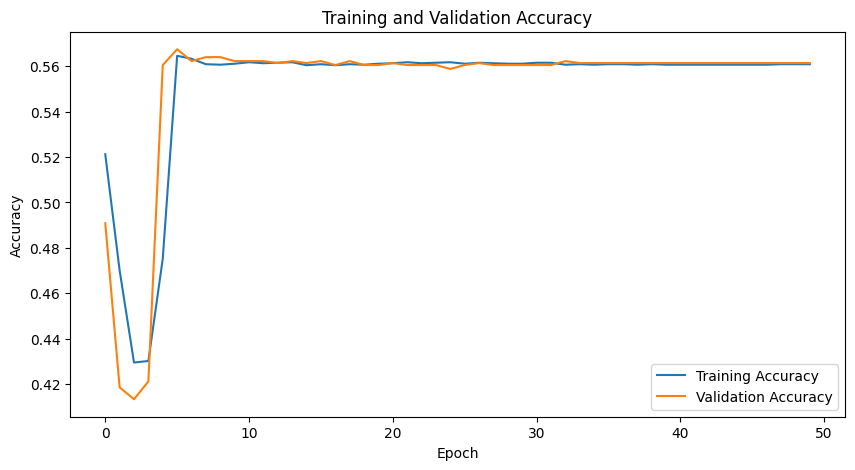

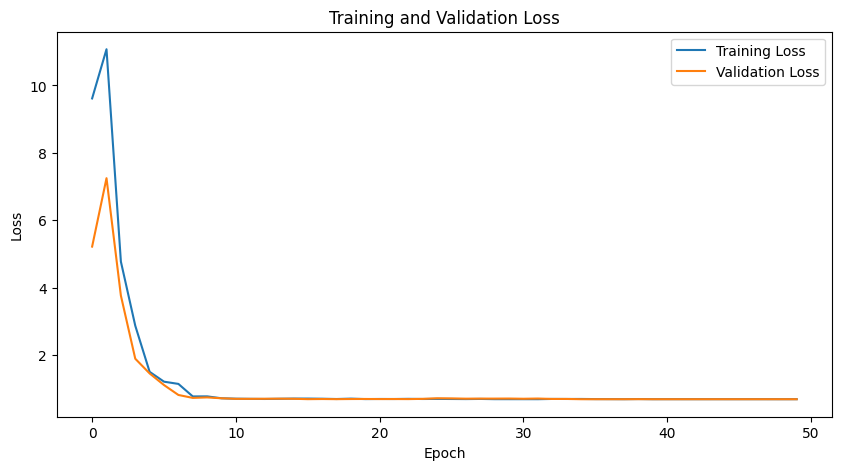

In [ ]:
# prompt: plot history_teacher0_main

import pandas as pd
import matplotlib.pyplot as plt

# Load the history data from the CSV file
history_df = pd.read_csv('/content/drive/MyDrive/USRF24/history_teacher0_main.csv')

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_df['binary_accuracy'], label='Training Accuracy')
plt.plot(history_df['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:

start_time = time.time()
history_teacher1_leg = teacher1.fit(train_images_leg, train_labels_leg, epochs=50, validation_data=(test_images_leg, test_labels_leg))
end_time = time.time()
training_time1 = end_time - start_time
print(f"Teacher 1 Training Time: {training_time1:.2f} seconds")


In [ ]:
# prompt: save history_teacher0_main as csv in drive

# Assuming history_teacher0_main is the training history object from model.fit
# Convert the history object to a pandas DataFrame
history_df = pd.DataFrame(history_teacher1_leg.history)

# Save the DataFrame to a CSV file in your Google Drive
history_df.to_csv('/content/drive/MyDrive/USRF24/history_teacher1_leg.csv', index=False)

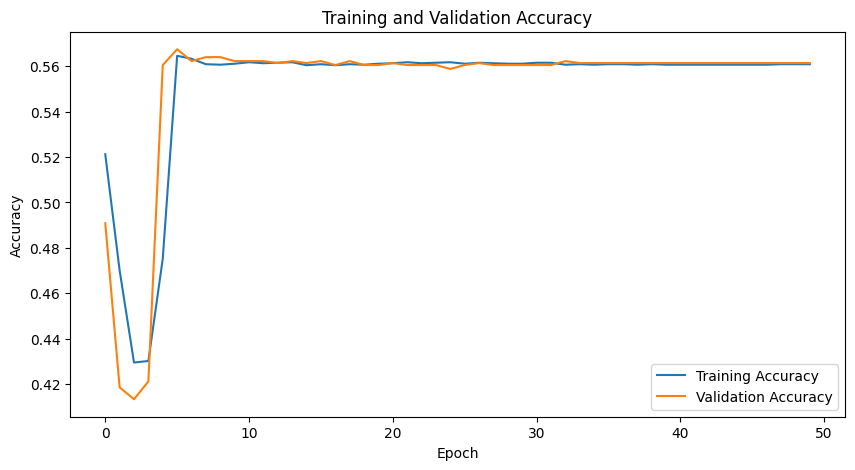

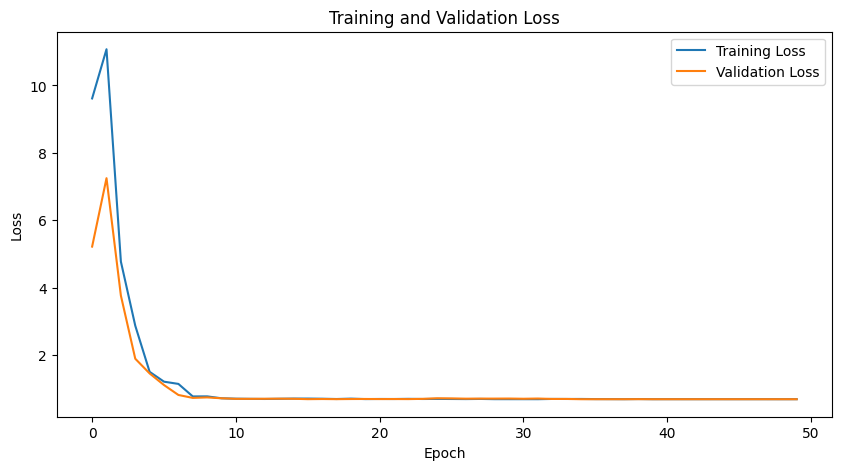

In [ ]:
# prompt: plot history_teacher0_main

import pandas as pd
import matplotlib.pyplot as plt

# Load the history data from the CSV file
history_df = pd.read_csv('/content/drive/MyDrive/USRF24/history_teacher1_leg.csv')

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_df['binary_accuracy'], label='Training Accuracy')
plt.plot(history_df['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
start_time = time.time()
history_teacher2_hand = teacher2.fit(train_images_hand, train_labels_hand, epochs=50, validation_data=(test_images_hand, test_labels_hand))
end_time = time.time()
training_time2 = end_time - start_time
print(f"Teacher 2 Training Time: {training_time2:.2f} seconds")

In [ ]:
# prompt: save history_teacher0_main as csv in drive

# Assuming history_teacher0_main is the training history object from model.fit
# Convert the history object to a pandas DataFrame
history_df = pd.DataFrame(history_teacher2_hand.history)

# Save the DataFrame to a CSV file in your Google Drive
history_df.to_csv('/content/drive/MyDrive/USRF24/history_teacher2_hand.csv', index=False)

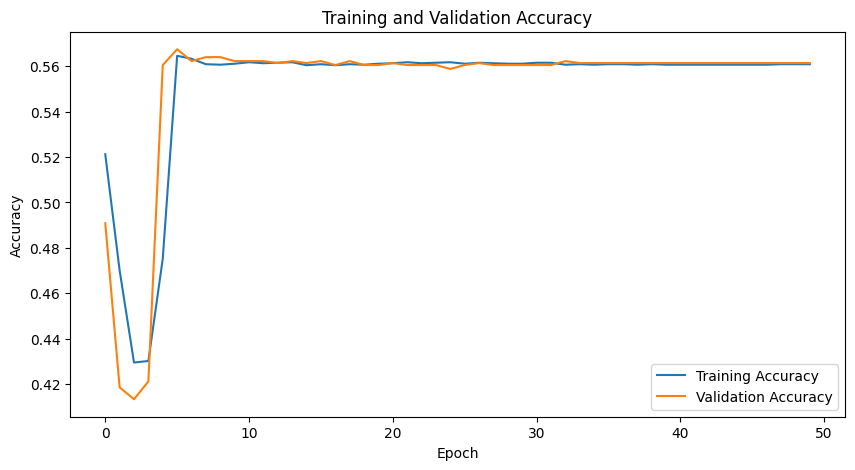

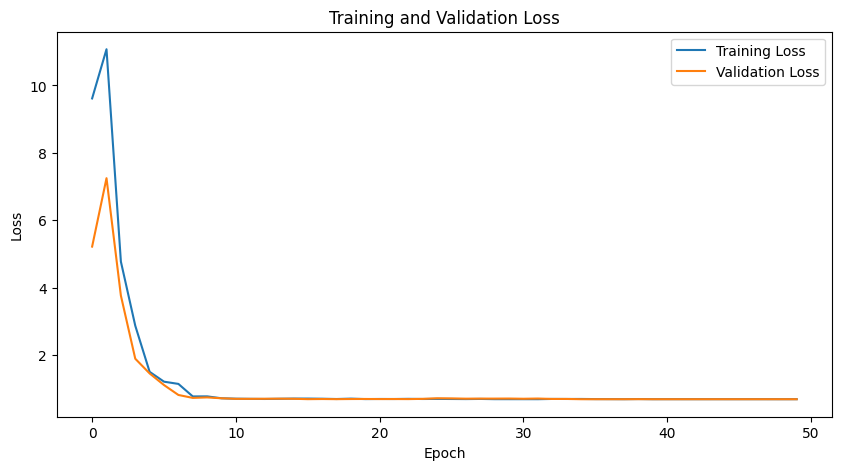

In [ ]:
# prompt: plot history_teacher0_main

import pandas as pd
import matplotlib.pyplot as plt

# Load the history data from the CSV file
history_df = pd.read_csv('/content/drive/MyDrive/USRF24/history_teacher2_hand.csv')

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_df['binary_accuracy'], label='Training Accuracy')
plt.plot(history_df['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
start_time = time.time()
history_teacher3_hip = teacher3.fit(train_images_hip, train_labels_hip, epochs=50, validation_data=(test_images_hip, test_labels_hip))
end_time = time.time()
training_time3 = end_time - start_time
print(f"Teacher 3 Training Time: {training_time3:.2f} seconds")

In [ ]:
# prompt: save history_teacher0_main as csv in drive

# Assuming history_teacher0_main is the training history object from model.fit
# Convert the history object to a pandas DataFrame
history_df = pd.DataFrame(history_teacher3_hip.history)

# Save the DataFrame to a CSV file in your Google Drive
history_df.to_csv('/content/drive/MyDrive/USRF24/history_teacher3_hip.csv', index=False)

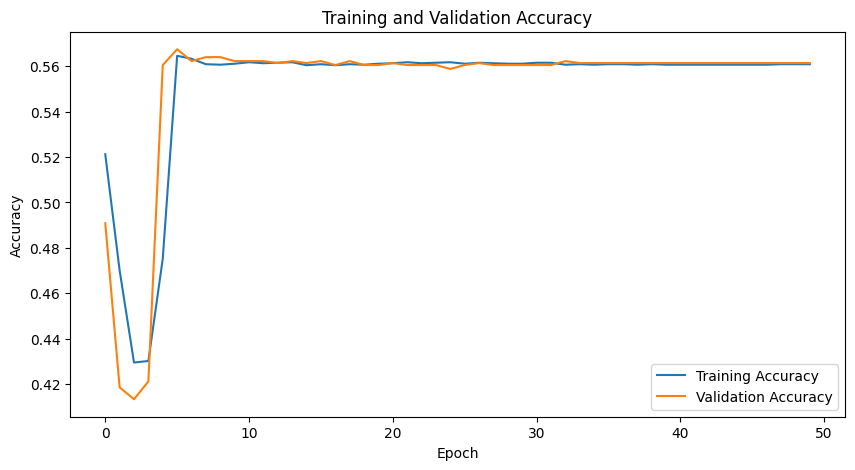

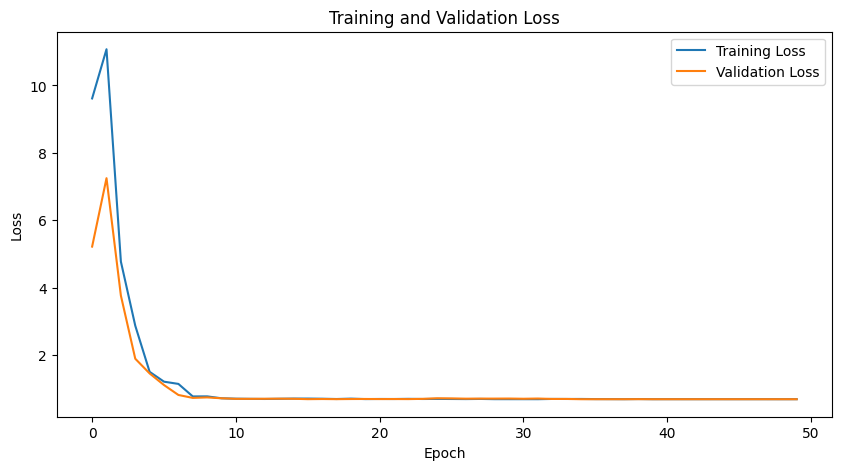

In [ ]:
# prompt: plot history_teacher0_main

import pandas as pd
import matplotlib.pyplot as plt

# Load the history data from the CSV file
history_df = pd.read_csv('/content/drive/MyDrive/USRF24/history_teacher3_hip.csv')

# Plot the training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_df['binary_accuracy'], label='Training Accuracy')
plt.plot(history_df['val_binary_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

# Plot the training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Deployment of student model and training

In [ ]:
import tensorflow as tf
from tensorflow import keras

class DistillerE(keras.Model):
    def __init__(self, student, teacher):
        """
        Initialize the distillation model with a student and teacher ensemble.
        Args:
            student: The student model (to be trained).
            teacher: A list of teacher models (ensemble).
        """
        super(DistillerE, self).__init__()
        self.teacher = teacher  # Ensemble of teacher models
        self.student = student  # The student model

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.1,
        temperature=3,
    ):
        """
        Configure the distiller with optimizer, loss functions, and metrics.
        Args:
            optimizer: Keras optimizer for student model.
            metrics: List of Keras metrics for evaluation.
            student_loss_fn: Loss function for student predictions vs. ground truth.
            distillation_loss_fn: Loss function for distillation (soft teacher vs. student).
            alpha: Weight to balance the student loss and distillation loss.
            temperature: Temperature for softening the probability distributions.
        """
        super(DistillerE, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn  # Loss function for student
        self.distillation_loss_fn = distillation_loss_fn  # Loss function for distillation
        self.alpha = alpha  # Weight for combining student and distillation losses
        self.temperature = temperature  # Temperature for softening the probability distributions

    def train_step(self, data):
        """
        Defines the training step for the distillation process.
        Args:
            data: A tuple of inputs (x) and labels (y).
        """
        x, y = data  # Inputs and ground truth labels

        # Forward pass through all teacher models and average the predictions
        predictions = self.teacher[0](x, training=False)  # First teacher model predictions
        for model in self.teacher[1:]:
            logits = model(x, training=False)  # Predictions from the other teacher models
            predictions += logits
        teacher_predictions = predictions / len(self.teacher)  # Average teacher predictions

        with tf.GradientTape() as tape:
            # Forward pass through the student model
            student_predictions = self.student(x, training=True)

            # Calculate the student loss (standard loss)
            student_loss = self.student_loss_fn(y, student_predictions)

            # Calculate the distillation loss (soft predictions of teacher vs student)
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis=1),  # Softened teacher predictions
                tf.nn.softmax(student_predictions / self.temperature, axis=1),  # Softened student predictions
            )

            # Total loss: weighted sum of student loss and distillation loss
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        # Compute gradients with respect to student model's trainable variables
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)

        # Apply gradients to update the student model's weights
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # Update the metrics based on student predictions
        self.compiled_metrics.update_state(y, student_predictions)

        # Return performance metrics and loss values
        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss
        })
        return results

    def test_step(self, data):
        """
        Defines the testing step to evaluate the student model.
        Args:
            data: A tuple of inputs (x) and labels (y).
        """
        x, y = data  # Inputs and ground truth labels

        # Compute the student model's predictions (without training)
        y_prediction = self.student(x, training=False)

        # Calculate the student loss (standard loss)
        student_loss = self.student_loss_fn(y, y_prediction)

        # Update the metrics based on student predictions
        self.compiled_metrics.update_state(y, y_prediction)

        # Return performance metrics and student loss
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})

        # Print the results for debugging purposes
        print('... test_step ...')
        print(results)

        return results


In [ ]:
# Define the student model
student = Sequential([
    # Convolutional layers
    Conv2D(8, (3, 3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D((2, 2)),
    TimeDistributed(layers.LSTM(10, activation='relu', return_sequences=False))

    # Flatten layer to transition from convolution to dense layers
    Flatten(),

    # Dense layers with dropout for regularization
    Dense(5, activation='relu'),
    Dropout(0.4),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification (0 or 1)
])
student.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
teachers = [teacher1, teacher2, teacher3]

In [ ]:
ssmt_dist = DistillerE(student=student, teacher=teachers)

# Compile the distiller model
ssmt_dist.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['binary_accuracy'],
    student_loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.25,  # Weight of the student loss in the final loss
    temperature=6,  # Temperature for distillation to soften the teacher's output
)

Epoch 1/50


/opt/conda/lib/python3.10/site-packages/keras/src/backend/tensorflow/nn.py:674: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
/opt/conda/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:578: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - binary_accuracy: 0.6693 - distillation_loss: 0.0000e+00 - loss: 0.4926 - student_loss: 0.5786... test_step ...
{'loss': <tf.Tensor 'div_no_nan_5:0' shape=() dtype=float32>, 'compile_metrics': {'binary_accuracy': <tf.Tensor 'div_no_nan_7:0' shape=() dtype=float32>}, 'student_loss': <tf.Tensor 'binary_crossentropy/truediv:0' shape=() dtype=float32>}
575/575 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - binary_accuracy: 0.6694 - distillation_loss: 0.0000e+00 - loss: 0.4926 - student_loss: 0.5786 - val_binary_accuracy: 0.8268 - val_loss: 0.4954 - val_student_loss: 0.5015
Epoch 2/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - binary_accuracy: 0.7867 - distillation_loss: 0.0000e+00 - loss: 0.4740 - student_loss: 0.4752 - val_binary_accuracy: 0.8442 - val_loss: 0.4958 - val_student_loss: 0.3963
Epoch 3/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 35s 61ms/step - binary_accuracy: 0.8154 - distillation_loss: 0.0000e+00 - loss: 0.4697 - student_loss: 0.4256 - val_binary_ac

In [ ]:
# prompt: train the model for hand, leg and hip data
import time

# Train the models
start_time = time.time()
# Distill teachers to student model
student2_history = ssmt_dist.fit(
    train_images_main,  # Training data
    train_labels_main,  # Training labels
    epochs=50,  # Number of epochs to train
    batch_size=batch_size,  # Batch size for training
    verbose=True,  # Set verbose to True to show progress
    validation_data=(test_images_main, test_labels_main)  # Validation data
)
end_time = time.time()
training_time0 = end_time - start_time
print(f"Student Training Time: {training_time0:.2f} seconds")


In [ ]:
history_df = pd.DataFrame(student2_history.history)

# Save the DataFrame to a CSV file in your Google Drive
history_df.to_csv('/content/drive/MyDrive/USRF24/history_student.csv', index=False)

# printing results

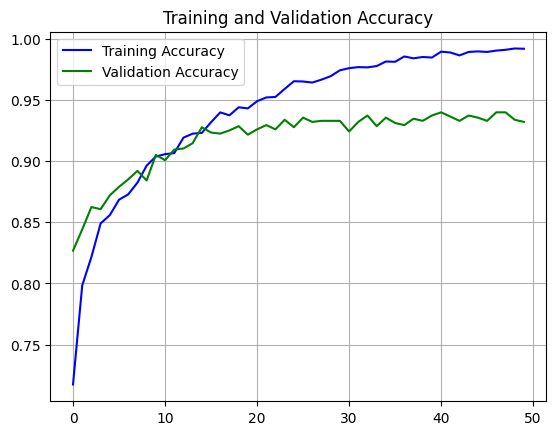

<Figure size 640x480 with 0 Axes>

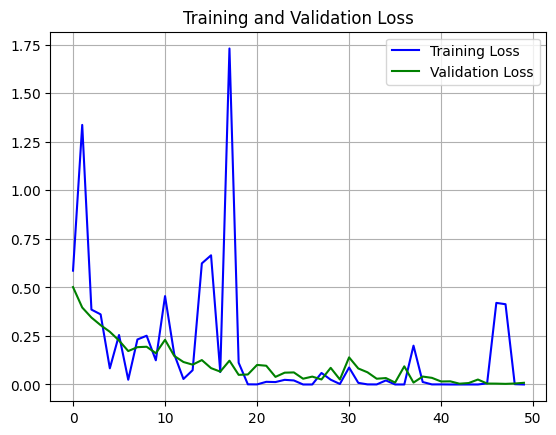

In [ ]:
# Extract history data from the student2 model training
train_acc_s2 = student2_history.history['binary_accuracy']  # Training accuracy
val_acc_s2 = student2_history.history['val_binary_accuracy']  # Validation accuracy
train_loss_s2 = student2_history.history['student_loss']  # Training loss
val_loss_s2 = student2_history.history['val_student_loss']  # Validation loss

import matplotlib.pyplot as plt

# Set up epochs range based on length of training history
epochs = range(len(train_acc_s2))

# Plot Training and Validation Accuracy
plt.plot(epochs, train_acc_s2, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc_s2, 'g', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.grid()
plt.legend()
plt.figure()
plt.show()

# Plot Training and Validation Loss
plt.plot(epochs, train_loss_s2, 'b', label='Training Loss')
plt.plot(epochs, val_loss_s2, 'g', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.grid()
plt.legend()
plt.show()


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       644
           1       0.92      0.93      0.93       505

    accuracy                           0.93      1149
   macro avg       0.93      0.93      0.93      1149
weighted avg       0.93      0.93      0.93      1149



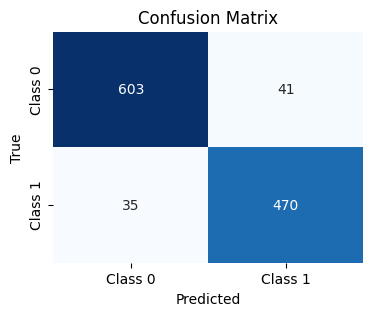

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming `student` is your trained model and `test_images_main`, `test_labels_main` are your test data
y_pred = student.predict(test_images_main)  # Get the predicted probabilities
y_pred_classes = (y_pred > 0.5).astype(int)  # Convert probabilities to class labels (0 or 1)

# Evaluate performance
print(classification_report(test_labels_main, y_pred_classes))  # Print classification report

# Confusion matrix
cm = confusion_matrix(test_labels_main, y_pred_classes)  # Calculate confusion matrix

# Plot confusion matrix using seaborn heatmap
plt.figure(figsize=(4,3))  # Set the figure size
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')  # Label for x-axis
plt.ylabel('True')  # Label for y-axis
plt.title('Confusion Matrix')  # Title of the plot
plt.show()  # Display the plot


Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9978 - distillation_loss: 0.0000e+00 - loss: 0.4425 - student_loss: 0.0177... test_step ...
{'loss': <tf.Tensor 'div_no_nan_5:0' shape=() dtype=float32>, 'compile_metrics': {'accuracy': <tf.Tensor 'div_no_nan_7:0' shape=() dtype=float32>}, 'student_loss': <tf.Tensor 'binary_crossentropy/truediv:0' shape=() dtype=float32>}
144/144 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.9978 - distillation_loss: 0.0000e+00 - loss: 0.4425 - student_loss: 0.0178 - val_accuracy: 0.9365 - val_loss: 0.4512 - val_student_loss: 0.4827
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - accuracy: 0.9981 - distillation_loss: 0.0000e+00 - loss: 0.4528 - student_loss: 0.0183 - val_accuracy: 0.9373 - val_loss: 0.4532 - val_student_loss: 0.5183
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9972 - distillation_loss: 0.0000e+00 - loss: 0.4421 - student_loss: 0.0217 - val_accuracy: 0.9373 - val_loss: 0.4486 - val_stude

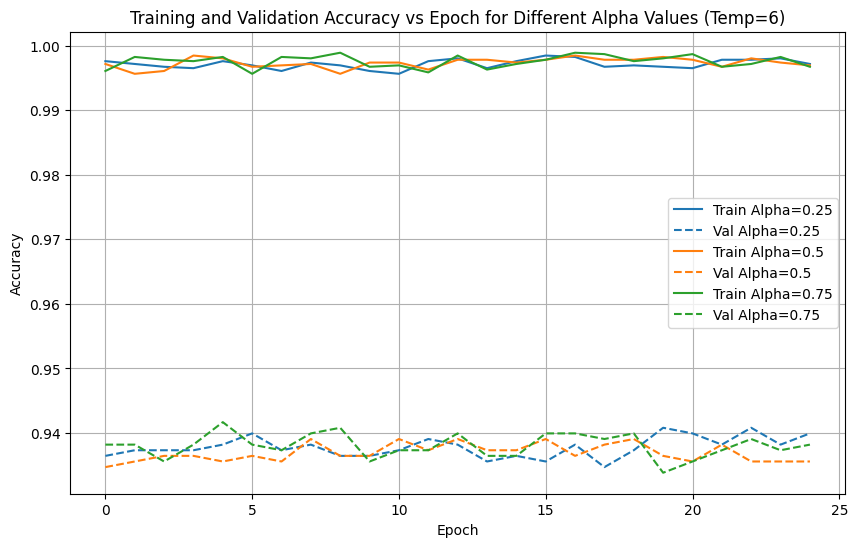

Epoch 1/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9975 - distillation_loss: 0.0000e+00 - loss: 0.4468 - student_loss: 0.0135... test_step ...
{'loss': <tf.Tensor 'div_no_nan_5:0' shape=() dtype=float32>, 'compile_metrics': {'accuracy': <tf.Tensor 'div_no_nan_7:0' shape=() dtype=float32>}, 'student_loss': <tf.Tensor 'binary_crossentropy/truediv:0' shape=() dtype=float32>}
144/144 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.9975 - distillation_loss: 0.0000e+00 - loss: 0.4468 - student_loss: 0.0136 - val_accuracy: 0.9382 - val_loss: 0.4548 - val_student_loss: 0.6188
Epoch 2/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9978 - distillation_loss: 0.0000e+00 - loss: 0.4415 - student_loss: 0.0123 - val_accuracy: 0.9382 - val_loss: 0.4604 - val_student_loss: 0.6690
Epoch 3/25
144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9970 - distillation_loss: 0.0000e+00 - loss: 0.4434 - student_loss: 0.0135 - val_accuracy: 0.9365 - val_loss: 0.4515 - val_student

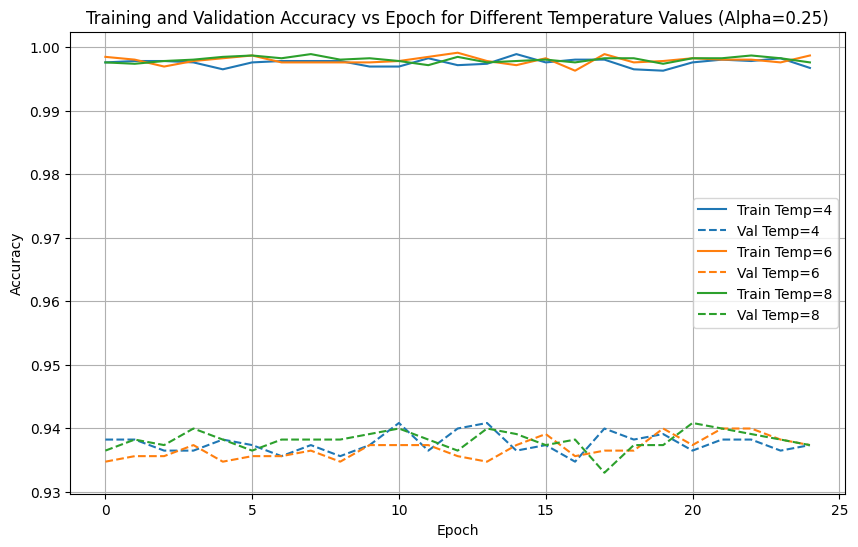

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# List of hyperparameters to try
learning_rate = 0.0001  # Fixed learning rate
temperatures = [4, 6, 8]  # Varying temperature values
alphas = [0.25, 0.5, 0.75]  # Varying alpha values

# Dictionary to store histories of different experiments
experiment_histories_alpha = {}  # To store alpha experiments
experiment_histories_temp = {}   # To store temperature experiments

# First: Fix learning rate and temperature, vary alpha
for alpha in alphas:
    # Fix temperature as 6 for this part
    temp = 6
    # Create the model
    ssmt_dist = DistillerE(student=student, teacher=teachers)

    # Compile the model with fixed learning rate and temperature
    ssmt_dist.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'],
        student_loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=alpha,
        temperature=temp,
    )

    # Train the model
    history = ssmt_dist.fit(
        train_images_main,
        train_labels_main,
        epochs=25,
        batch_size=32,
        verbose=True,
        validation_data=(test_images_main, test_labels_main)
    )

    #save the csv files of the data generated
    history_df = pd.DataFrame(history.history)

    # Save the DataFrame to a CSV file in your Google Drive
    history_df.to_csv(f'/content/drive/MyDrive/USRF24/history_student_aplha_{alpha}.csv', index=False)

    # Store the result
    experiment_name = f"lr_{learning_rate}_alpha_{alpha}_temp_{temp}"
    experiment_histories_alpha[experiment_name] = history

# Plot training and validation accuracy vs epoch for different alpha values (fixed temp)
plt.figure(figsize=(10, 6))
for alpha in alphas:
    # Extract accuracy and validation accuracy from history
    experiment_name = f"lr_{learning_rate}_alpha_{alpha}_temp_6"
    history = experiment_histories_alpha[experiment_name]

    # Plot training accuracy
    plt.plot(history.history['accuracy'], label=f'Train Alpha={alpha}', linestyle='-', color=f'C{alphas.index(alpha)}')
    # Plot validation accuracy
    plt.plot(history.history['val_accuracy'], label=f'Val Alpha={alpha}', linestyle='--', color=f'C{alphas.index(alpha)}')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs Epoch for Different Alpha Values (Temp=6)')
plt.legend()
plt.grid(True)
plt.show()

# Second: Fix learning rate and alpha, vary temperature
alpha_fixed = 0.25  # Fixed alpha
for temp in temperatures:
    # Fix alpha as 0.25 for this part
    # Create the model
    ssmt_dist = DistillerE(student=student, teacher=teachers)

    # Compile the model with fixed learning rate and alpha
    ssmt_dist.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'],
        student_loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=alpha_fixed,
        temperature=temp,
    )

    # Train the model
    history = ssmt_dist.fit(
        train_images_main,
        train_labels_main,
        epochs=25,
        batch_size=32,
        verbose=True,
        validation_data=(test_images_main, test_labels_main)
    )

    #save the csv files of the data generated
    history_df = pd.DataFrame(history.history)

    # Save the DataFrame to a CSV file in your Google Drive
    history_df.to_csv(f'/content/drive/MyDrive/USRF24/history_student_temp_{temp}.csv', index=False)

    # Store the result
    experiment_name = f"lr_{learning_rate}_alpha_{alpha_fixed}_temp_{temp}"
    experiment_histories_temp[experiment_name] = history

# Plot training and validation accuracy vs epoch for different temperature values (fixed alpha=0.25)
plt.figure(figsize=(10, 6))
for temp in temperatures:
    # Extract accuracy and validation accuracy from history
    experiment_name = f"lr_{learning_rate}_alpha_{alpha_fixed}_temp_{temp}"
    history = experiment_histories_temp[experiment_name]

    # Plot training accuracy
    plt.plot(history.history['accuracy'], label=f'Train Temp={temp}', linestyle='-', color=f'C{temperatures.index(temp)}')
    # Plot validation accuracy
    plt.plot(history.history['val_accuracy'], label=f'Val Temp={temp}', linestyle='--', color=f'C{temperatures.index(temp)}')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs Epoch for Different Temperature Values (Alpha=0.25)')
plt.legend()
plt.grid(True)
plt.show()


#Unused program

In [ ]:
'''
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, TimeDistributed, LSTM, Dense, Dropout

# Define the input layer
input_shape = (128, 128, 3)  # Example input shape (height, width, channels)
inputs = Input(shape=input_shape)

# Define the first convolutional head
x1 = layers.Conv2D(8, (3, 3), padding='same', activation='relu')(inputs)
x1 = layers.MaxPooling2D((2, 2))(x1)
x1 = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(x1)
x1 = layers.MaxPooling2D((2, 2))(x1)

# Define the second convolutional head
x2 = layers.Conv2D(8, (5, 5), padding='same', activation='relu')(inputs)
x2 = layers.MaxPooling2D((2, 2))(x2)
x2 = layers.Conv2D(16, (5, 5), padding='same', activation='relu')(x2)
x2 = layers.MaxPooling2D((2, 2))(x2)

# Concatenate the outputs of the convolutional heads
concatenated = layers.concatenate([x1, x2])

# Add TimeDistributed LSTM layer
x1 = TimeDistributed(layers.LSTM(30, activation='tanh', return_sequences=False))(concatenated)

# Flatten the output before feeding into dense layers
x = layers.Flatten()(x1)

# Add dense layers
x = layers.Dense(5, activation='relu')(x)
x = layers.Dropout(0.4)(x)

# Output layer for binary classification (sigmoid activation)
outputs = layers.Dense(1, activation='sigmoid')(x)

# Create the models
teacher1 = models.Model(inputs, outputs)
teacher2 = models.Model(inputs, outputs)
teacher3 = models.Model(inputs, outputs)

# Print the model summaries
print("Teacher 1 Model Summary:")
teacher1.summary()

print("\nTeacher 2 Model Summary:")
teacher2.summary()

print("\nTeacher 3 Model Summary:")
teacher3.summary()
'''

'\nfrom tensorflow.keras import layers, models\nfrom tensorflow.keras.layers import Input, TimeDistributed, LSTM, Dense, Dropout\n\n# Define the input layer\ninput_shape = (128, 128, 3)  # Example input shape (height, width, channels)\ninputs = Input(shape=input_shape)\n\n# Define the first convolutional head\nx1 = layers.Conv2D(8, (3, 3), padding=\'same\', activation=\'relu\')(inputs)\nx1 = layers.MaxPooling2D((2, 2))(x1)\nx1 = layers.Conv2D(16, (3, 3), padding=\'same\', activation=\'relu\')(x1)\nx1 = layers.MaxPooling2D((2, 2))(x1)\n\n# Define the second convolutional head\nx2 = layers.Conv2D(8, (5, 5), padding=\'same\', activation=\'relu\')(inputs)\nx2 = layers.MaxPooling2D((2, 2))(x2)\nx2 = layers.Conv2D(16, (5, 5), padding=\'same\', activation=\'relu\')(x2)\nx2 = layers.MaxPooling2D((2, 2))(x2)\n\n# Concatenate the outputs of the convolutional heads\nconcatenated = layers.concatenate([x1, x2])\n\n# Add TimeDistributed LSTM layer\nx1 = TimeDistributed(layers.LSTM(30, activation=\'t

In [ ]:
# Data Augmentation using ImageDataGeneratortrain_d# Data Augmentation using ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Main dataset generators
train_generator_main = train_datagen.flow(
    train_images_main, train_labels_main, batch_size=batch_size
)
validation_generator_main = test_datagen.flow(
    test_images_main, test_labels_main, batch_size=batch_size
)

# Hand dataset generators
train_generator_hand = train_datagen.flow(
    train_images_hand, train_labels_hand, batch_size=batch_size
)
validation_generator_hand = test_datagen.flow(
    test_images_hand, test_labels_hand, batch_size=batch_size
)

# Leg dataset generators
train_generator_leg = train_datagen.flow(
    train_images_leg, train_labels_leg, batch_size=batch_size
)
validation_generator_leg = test_datagen.flow(
    test_images_leg, test_labels_leg, batch_size=batch_size
)

# Hip dataset generators
train_generator_hip = train_datagen.flow(
    train_images_hip, train_labels_hip, batch_size=batch_size
)
validation_generator_hip = test_datagen.flow(
    test_images_hip, test_labels_hip, batch_size=batch_size
)
